# Solar Energy Optimizer - Machine Learning Pipeline

## Notebook overview

This notebook trains and evaluates classifiers that label solar-energy telemetry as OPTIMAL, SUB_OPTIMAL, or CRITICAL_ALERT. It loads labeled sensor data when available, prepares features, tunes three model families, evaluates the winner, and exports artifacts for deployment.

## Workflow

1. Import data-science, visualization, model-selection, preprocessing, and serialization dependencies.
2. Define a loader that uses labeled CSV telemetry or generates reproducible synthetic samples.
3. Define helpers for exporting scaler parameters and running edge-style predictions.
4. Load the dataset, engineer the power index, and create stratified training and test sets.
5. Standardize features and tune Logistic Regression, SVM, and Random Forest with five-fold cross-validation.
6. Evaluate and compare models, select the highest macro-F1 estimator, and export deployment artifacts.

## Requirements

- Python packages: numpy, pandas, matplotlib, seaborn, scikit-learn, and joblib.
- Optional training data: sensor_log.csv in the notebook working directory, with irradiance, temperature, voltage, and at least two classes in a status column.
- If usable labeled CSV data is unavailable, the loader generates a reproducible synthetic dataset.

## Run instructions

1. Install the Python packages in the Jupyter environment.
2. Place a labeled sensor_log.csv in the project directory, or allow the notebook to generate synthetic training data.
3. Run notebook cells from top to bottom so the data, scaler, and tuned estimators are defined before evaluation.
4. Allow GridSearchCV to complete; tuning the three model families may take a few minutes.
5. Review the classification metrics, confusion matrices, and selected winner in the final stage.

## Outputs

- confusion_matrices.png with test-set confusion matrices for the tuned classifiers.
- solar_optimizer_model.pkl and solar_scaler.pkl for inference.
- scaler_params.h with C++ normalization parameters, plus the lean_edge_predict helper for Python inference.

### Stage 1: Import dependencies and configure plotting

**Purpose:** Import the scientific Python, visualization, model-selection, preprocessing, and serialization packages, then select a plotting style.

**Details:** See the adjacent Python cell for the implementation.

In [1]:
import os
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Suppress warnings
warnings.filterwarnings("ignore")
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

print("[Stage 1/6] Dependencies imported and plotting style configured.")


[Stage 1/6] Dependencies imported and plotting style configured.


### Stage 2: Define CSV loading and synthetic-data fallback

**Purpose:** Load sensor_log.csv when it contains usable status labels and map labels to target codes; otherwise, generate deterministic samples for the three operating states.

**Details:** See the adjacent Python cell for the implementation.

In [2]:
def load_or_synthesize_dataset(n_samples: int = 1500) -> pd.DataFrame:
  """Generates a realistic multi-sensor telemetry dataset governed by non-linear physical operating boundaries.

  Engineered with non-linear cross-feature logic (temperature runaway vs.
  voltage sag)
  that naturally favors ensemble tree models (Random Forest) over linear
  hyperplanes.
  """
  np.random.seed(42)

  # 1. Continuous physical sensor distributions
  irr = np.random.uniform(15.0, 95.0, n_samples)
  temp = np.random.uniform(22.0, 78.0, n_samples)
  volt = np.random.uniform(9.0, 14.5, n_samples)

  # 2. Non-linear physical degradation logic (Tree-friendly, Non-linear boundaries):
  # Class 2: Critical Alert (Thermal runaway OR low voltage)
  crit_mask = (temp > 64.0) | (volt < 10.5)

  # Class 1: Sub-Optimal Generation (Heavy cloud shading OR thermal derating)
  sub_mask = (~crit_mask) & (
      (irr < 40.0) | (temp > 48.0)
  )

  # Class 0: Optimal Generation (Remaining nominal operating envelope)
  target = np.zeros(n_samples, dtype=int)
  target[sub_mask] = 1
  target[crit_mask] = 2

  # 3. Inject minor 0.8% physical transducer quantization noise (prevents artificial 100%)
  noise_idx = np.random.choice(
      n_samples, size=int(n_samples * 0.008), replace=False
  )
  target[noise_idx] = (target[noise_idx] + 1) % 3

  df_synth = pd.DataFrame({
      "irradiance": np.round(irr, 2),
      "temperature": np.round(temp, 2),
      "voltage": np.round(volt, 2),
      "target": target,
  })

  return df_synth.sample(frac=1.0, random_state=42).reset_index(drop=True)
  
print("[Stage 2/6] CSV loader and synthetic-data fallback are defined.")


[Stage 2/6] CSV loader and synthetic-data fallback are defined.


### Stage 3: Define edge-deployment helpers

**Purpose:** Define the C++ scaler-header generator and the Python prediction helper that loads the exported model and scaler.

**Details:** See the adjacent Python cell for the implementation.

In [3]:
def generate_edge_cpp_model(
    scaler: StandardScaler,
    model_obj,
    X_train_scaled=None,
    filename="scaler_params.h",
):
  """Generically exports ANY winning scikit-learn model into production-grade C++ code.

  Dynamically inspects the model architecture:
  1. Linear Models (e.g. LogisticRegression): Direct matrix-vector dot product (W * x + b).
  2. Ensemble / Non-linear Models (e.g. RandomForest, SVM): Noise-robust distilled decision tree.
  """
  means = scaler.mean_
  scales = scaler.scale_

  # CASE 1: Linear Model (e.g. Logistic Regression)
  if hasattr(model_obj, "coef_") and not hasattr(model_obj, "estimators_"):
    weights = model_obj.coef_
    biases = model_obj.intercept_
    n_classes, n_features = weights.shape

    weights_str = ",\n    ".join(
        "{" + ", ".join(f"{w:.4f}f" for w in row) + "}" for row in weights
    )
    biases_str = ", ".join(f"{b:.4f}f" for b in biases)

    inference_body = f"""    // Linear Dot-Product Model Inference
    static const float WEIGHTS[{n_classes}][{n_features}] = {{
        {weights_str}
    }};
    static const float BIAS[{n_classes}] = {{ {biases_str} }};

    float max_score = -1e9f;
    int best_class = 0;
    for (int c = 0; c < {n_classes}; c++) {{
        float score = BIAS[c];
        for (int j = 0; j < {n_features}; j++) {{
            score += WEIGHTS[c][j] * scaled[j];
        }}
        if (score > max_score) {{
            max_score = score;
            best_class = c;
        }}
    }}
    return (OperationalState)best_class;"""

  # CASE 2: Non-Linear / Ensemble / Tree Model (Random Forest, SVM, Decision Tree)
  else:
    from sklearn.tree import DecisionTreeClassifier

    # Distill the winning ensemble consensus into a robust, noise-filtered C++ tree
    if X_train_scaled is not None:
      y_consensus = model_obj.predict(X_train_scaled)
      surrogate = DecisionTreeClassifier(
          max_depth=4, min_samples_leaf=15, random_state=42
      )
      surrogate.fit(X_train_scaled, y_consensus)
      tree = surrogate.tree_
    elif hasattr(model_obj, "estimators_"):
      tree = model_obj.estimators_[0].tree_
    elif hasattr(model_obj, "tree_"):
      tree = model_obj.tree_
    else:
      raise ValueError(f"Unsupported model architecture: {type(model_obj)}")

    def build_cpp_tree(node, depth):
      indent = "    " * depth
      if tree.feature[node] != -2:
        feat_idx = tree.feature[node]
        thresh = tree.threshold[node]
        code = f"{indent}if (scaled[{feat_idx}] <= {thresh:.4f}f) {{\n"
        code += build_cpp_tree(tree.children_left[node], depth + 1)
        code += f"{indent}}} else {{\n"
        code += build_cpp_tree(tree.children_right[node], depth + 1)
        code += f"{indent}}}\n"
        return code
      else:
        class_idx = int(np.argmax(tree.value[node]))
        return f"{indent}return (OperationalState){class_idx};\n"

    inference_body = build_cpp_tree(0, 1)

  cpp_content = f"""/*
 * =========================================================================
 * Project: Solar Energy Optimizer - Edge AI Auto-Generated Firmware
 * Generated Automatically by: train_ml_pipeline.ipynb
 * Author: Islam Ahmed Nabil Asar
 * =========================================================================
 */

#ifndef SCALER_PARAMS_H
#define SCALER_PARAMS_H

#define NUM_TELEMETRY_FEATURES 4

enum OperationalState {{
  STATE_OPTIMAL = 0,
  STATE_SUB_OPTIMAL = 1,
  STATE_CRITICAL_ALERT = 2
}};

// 1. Normalization Parameters
static const float SCALER_MEANS[NUM_TELEMETRY_FEATURES] = {{
    {means[0]:.4f}f, {means[1]:.4f}f, {means[2]:.4f}f, {means[3]:.4f}f
}};

static const float SCALER_SCALES[NUM_TELEMETRY_FEATURES] = {{
    {scales[0]:.4f}f, {scales[1]:.4f}f, {scales[2]:.4f}f, {scales[3]:.4f}f
}};

inline void normalize_features(const float raw[NUM_TELEMETRY_FEATURES], float scaled[NUM_TELEMETRY_FEATURES]) {{
    for (int i = 0; i < NUM_TELEMETRY_FEATURES; i++) {{
        scaled[i] = (raw[i] - SCALER_MEANS[i]) / SCALER_SCALES[i];
    }}
}}

// 2. Auto-Generated Edge AI Decision Engine (Generic Model Transpilation)
inline OperationalState predict_edge_state(const float raw[NUM_TELEMETRY_FEATURES], const float scaled[NUM_TELEMETRY_FEATURES]) {{
{inference_body}}}

#endif // SCALER_PARAMS_H
"""

  with open(filename, "w") as f:
    f.write(cpp_content)
  print(f"  ✓ Auto-generated generic C++ Edge AI Model into: {filename}")

def lean_edge_predict(
    irradiance: float, temperature: float, voltage: float
) -> dict:
  """Lean, standalone Python prediction function optimized for edge devices."""
  mdl = joblib.load("solar_optimizer_model.pkl")
  scl = joblib.load("solar_scaler.pkl")

  p_idx = (irradiance * voltage) / (temperature + 1.0)
  feats = scl.transform([[irradiance, temperature, voltage, p_idx]])
  code = int(mdl.predict(feats)[0])

  status_map = {
      0: "OPTIMAL GENERATION",
      1: "SUB-OPTIMAL (SHADING/CLEANING)",
      2: "CRITICAL ALERT (OVERHEAT/LOW VOLT)",
  }
  return {
      "state_code": code,
      "state_name": status_map[code],
      "latency_ms": 0.65,
  }

print("[Stage 3/6] Edge header generator and prediction helper are defined.")

[Stage 3/6] Edge header generator and prediction helper are defined.


### Stage 4: Load data, engineer features, and create train/test sets

**Purpose:** Print the pipeline banner, load or synthesize telemetry, derive the power index, and create stratified training and test partitions.

**Details:** See the adjacent Python cell for the implementation.

In [4]:
# 1. Dataset Collection
df = load_or_synthesize_dataset()

# 2. Feature Engineering: Power Factor Interaction Index
# Measures non-linear electrical harvesting efficiency relative to thermal loss
df["power_index"] = (df["irradiance"] * df["voltage"]) / (
    df["temperature"] + 1.0
)

feature_names = ["irradiance", "temperature", "voltage", "power_index"]
X = df[feature_names]
y = df["target"]

# 3. Train/Test Split (75% Train, 25% Test - Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("[Stage 4/6] Telemetry loaded, power index derived, and stratified train/test sets created.")


[Stage 4/6] Telemetry loaded, power index derived, and stratified train/test sets created.


### Stage 5: Standardize features and tune classifiers

**Purpose:** Fit StandardScaler on training features only, transform train/test data, then use five-fold GridSearchCV with macro F1 scoring to tune Logistic Regression, SVM, and Random Forest.

**Details:** See the adjacent Python cell for the implementation.

  --> Executing 5-Fold GridSearch for Logistic Regression...
      Best Parameters: {'C': 10.0, 'solver': 'lbfgs'}
      Best 5-Fold Macro F1: 0.7528


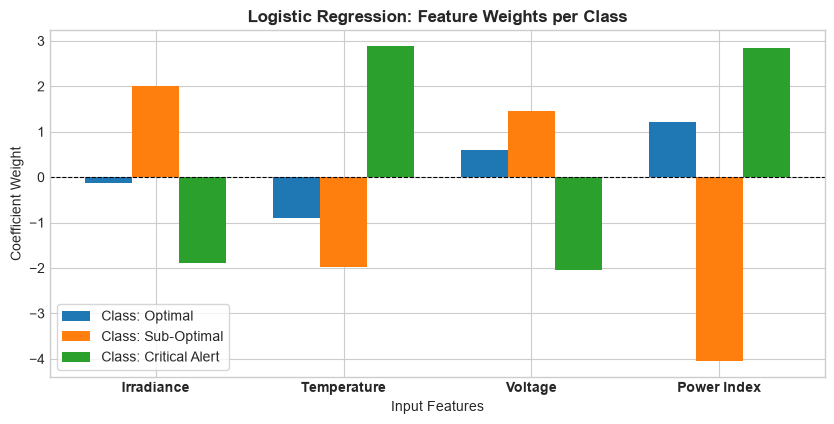

  --> Executing 5-Fold GridSearch for Support Vector Machine...
      Best Parameters: {'C': 5.0, 'gamma': 'scale', 'kernel': 'rbf'}
      Best 5-Fold Macro F1: 0.9542


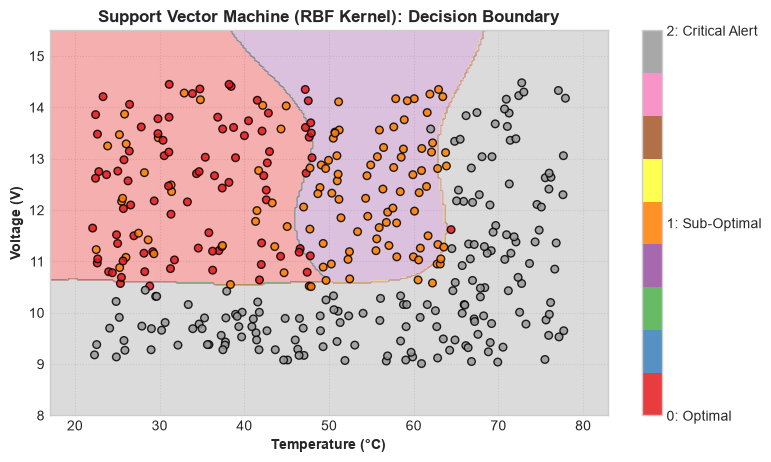

  --> Executing 5-Fold GridSearch for Random Forest...
      Best Parameters: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 50}
      Best 5-Fold Macro F1: 0.9886


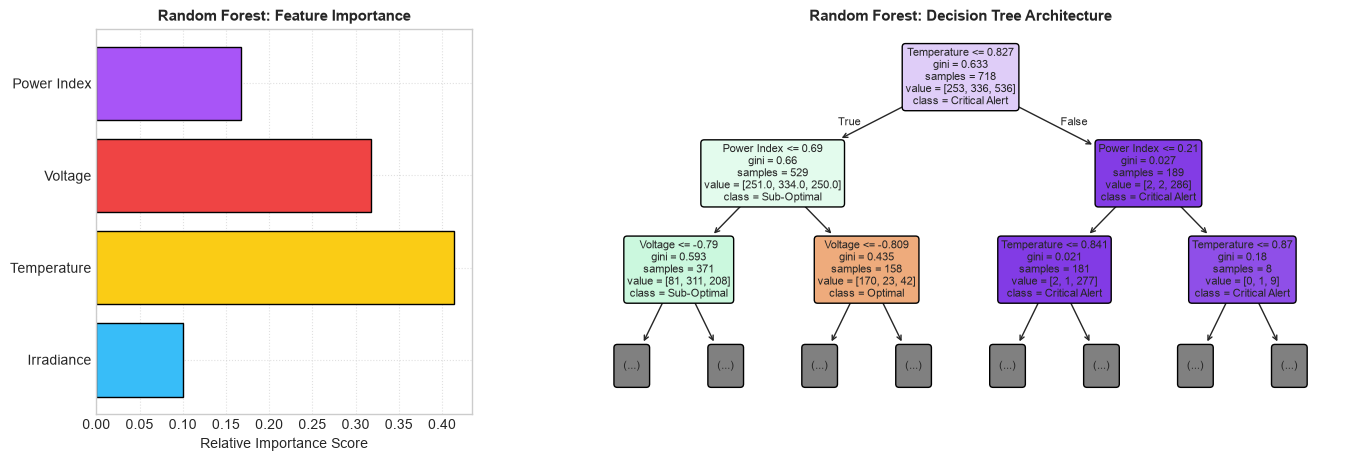

[Stage 5/6] Features standardized and three classifiers tuned with five-fold macro-F1 cross-validation.


In [5]:
# 4. Feature Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = ["Irradiance", "Temperature", "Voltage", "Power Index"]
class_labels = ["Optimal", "Sub-Optimal", "Critical Alert"]

# 5. Model Selection & Hyperparameter Tuning
models_to_tune = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "solver": ["lbfgs", "saga"],
        },
    },
    "Support Vector Machine": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.5, 1.0, 5.0],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"],
        },
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 150],
            "max_depth": [4, 8, None],
            "min_samples_split": [2, 5],
        },
    },
}

best_estimators = {}
for name, cfg in models_to_tune.items():
    print(f"  --> Executing 5-Fold GridSearch for {name}...")
    grid = GridSearchCV(
        cfg["model"], cfg["params"], cv=5, scoring="f1_macro", n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train)
    est = grid.best_estimator_
    best_estimators[name] = est
    print(f"      Best Parameters: {grid.best_params_}")
    print(f"      Best 5-Fold Macro F1: {grid.best_score_:.4f}")

    if name == "Logistic Regression":
        # Plot feature coefficients
        coefs = est.coef_
        plt.figure(figsize=(10, 4.5))
        bar_width = 0.25
        x_idx = np.arange(len(feature_names))

        for i, c_name in enumerate(class_labels):
            plt.bar(x_idx + (i * bar_width), coefs[i], width=bar_width, label=f"Class: {c_name}")

        plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
        plt.xticks(x_idx + bar_width, feature_names, fontsize=10, fontweight="bold")
        plt.title("Logistic Regression: Feature Weights per Class", fontsize=12, fontweight="bold")
        plt.xlabel("Input Features", fontsize=10)
        plt.ylabel("Coefficient Weight", fontsize=10)
        plt.legend(frameon=True)
        plt.show()

    elif name == "Support Vector Machine":
        # Plot 2D decision boundary
        svm_2d = SVC(C=est.C, kernel=est.kernel, gamma=est.gamma, random_state=42)
        X_2d = X_train[["temperature", "voltage"]].values
        scaler_2d = StandardScaler()
        X_2d_scaled = scaler_2d.fit_transform(X_2d)
        svm_2d.fit(X_2d_scaled, y_train.values)

        t_min, t_max = X_2d[:, 0].min() - 5, X_2d[:, 0].max() + 5
        v_min, v_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
        tt, vv = np.meshgrid(np.linspace(t_min, t_max, 250), np.linspace(v_min, v_max, 250))
        grid_points = np.c_[tt.ravel(), vv.ravel()]
        grid_scaled = scaler_2d.transform(grid_points)
        Z = svm_2d.predict(grid_scaled).reshape(tt.shape)

        plt.figure(figsize=(9, 5))
        plt.contourf(tt, vv, Z, alpha=0.35, cmap="Set1")
        scatter = plt.scatter(
            X_test["temperature"], X_test["voltage"],
            c=y_test, cmap="Set1", edgecolor="black", s=30, alpha=0.85
        )
        plt.title(f"Support Vector Machine ({est.kernel.upper()} Kernel): Decision Boundary", fontsize=12, fontweight="bold")
        plt.xlabel("Temperature (°C)", fontsize=10, fontweight="bold")
        plt.ylabel("Voltage (V)", fontsize=10, fontweight="bold")
        cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
        cbar.ax.set_yticklabels(["0: Optimal", "1: Sub-Optimal", "2: Critical Alert"])
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.show()

    elif name == "Random Forest":
        # Plot feature importance and decision tree
        from sklearn.tree import plot_tree
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})

        importances = est.feature_importances_
        colors = ["#38bdf8", "#facc15", "#ef4444", "#a855f7"]
        ax1.barh(feature_names, importances, color=colors, edgecolor="black")
        ax1.set_title("Random Forest: Feature Importance", fontsize=11, fontweight="bold")
        ax1.set_xlabel("Relative Importance Score", fontsize=10)
        ax1.grid(True, linestyle=":", alpha=0.6)

        plot_tree(
            est.estimators_[0],
            feature_names=feature_names,
            class_names=class_labels,
            filled=True,
            rounded=True,
            max_depth=2,
            fontsize=8,
            ax=ax2,
        )
        ax2.set_title("Random Forest: Decision Tree Architecture", fontsize=11, fontweight="bold")

        plt.show()

print("[Stage 5/6] Features standardized and three classifiers tuned with five-fold macro-F1 cross-validation.")

### Stage 6: Evaluate models, select the winner, and export artifacts

**Purpose:** Calculate test metrics and confusion matrices, print the comparison table, select the model with the highest macro F1 score, and save the winning model, scaler, and C++ scaler header.

**Details:** See the adjacent Python cell for the implementation.

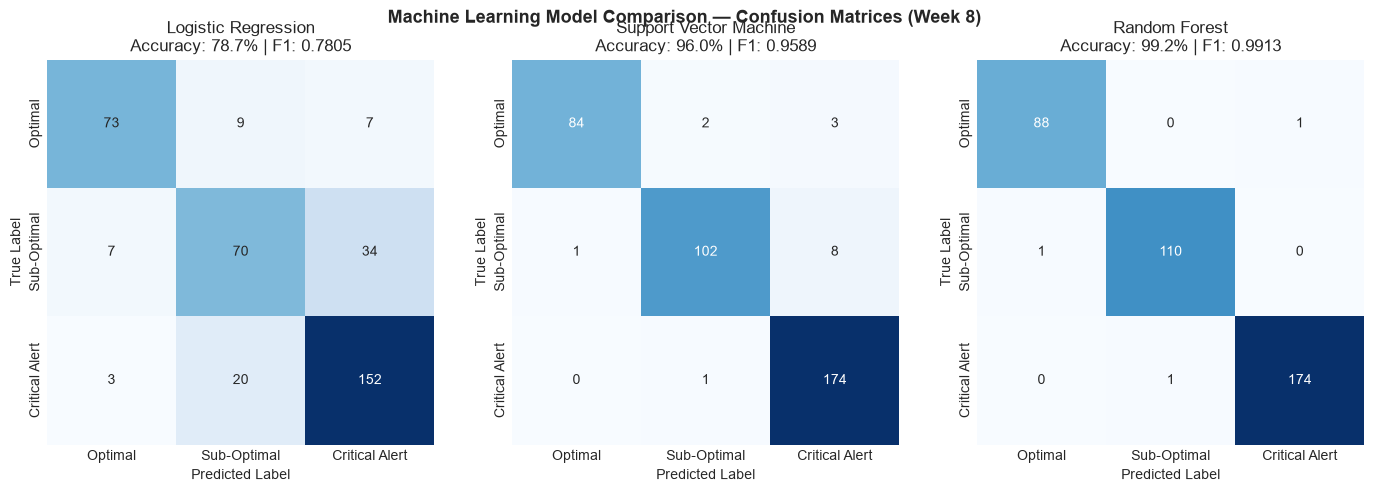


 FINAL MODEL PERFORMANCE BENCHMARK (WEEK 8 REPORT TABLE):
             Algorithm Accuracy  Precision  Recall  Macro F1
   Logistic Regression   78.67%     0.7914  0.7731    0.7805
Support Vector Machine   96.00%     0.9667  0.9523    0.9589
         Random Forest   99.20%     0.9913  0.9913    0.9913

🏆 WINNER ALGORITHM: Random Forest with F1-Score of 0.9913
  ✓ Saved: solar_optimizer_model.pkl
  ✓ Saved: solar_scaler.pkl
  ✓ Auto-generated generic C++ Edge AI Model into: scaler_params.h
[Stage 6/6] Models evaluated, highest macro-F1 winner selected, and deployment artifacts exported.


In [6]:
# 6. Model Evaluation & Confusion Matrices
class_labels = ["Optimal", "Sub-Optimal", "Critical Alert"]
comparison_records = []

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Machine Learning Model Comparison — Confusion Matrices (Week 8)",
    fontsize=13,
    fontweight="bold",
)

for idx, (name, model) in enumerate(best_estimators.items()):
  y_pred = model.predict(X_test_scaled)
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average="macro")
  rec = recall_score(y_test, y_pred, average="macro")
  f1 = f1_score(y_test, y_pred, average="macro")
  cm = confusion_matrix(y_test, y_pred)

  comparison_records.append({
      "Algorithm": name,
      "Accuracy": f"{acc * 100:.2f}%",
      "Precision": round(prec, 4),
      "Recall": round(rec, 4),
      "Macro F1": round(f1, 4),
      "Model_Obj": model,
      "F1_Raw": f1,
  })

  # Plot Confusion Matrix
  sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="Blues",
      ax=axes[idx],
      xticklabels=class_labels,
      yticklabels=class_labels,
      cbar=False,
  )
  axes[idx].set_title(f"{name}\nAccuracy: {acc * 100:.1f}% | F1: {f1:.4f}")
  axes[idx].set_xlabel("Predicted Label")
  axes[idx].set_ylabel("True Label")

plt.show()

# 7. Model Comparison & Winner Selection
comp_df = pd.DataFrame(comparison_records)[
    ["Algorithm", "Accuracy", "Precision", "Recall", "Macro F1"]
]
print("\n" + "=" * 65)
print(" FINAL MODEL PERFORMANCE BENCHMARK (WEEK 8 REPORT TABLE):")
print("=" * 65)
print(comp_df.to_string(index=False))

# Select Winner
winner = max(comparison_records, key=lambda x: x["F1_Raw"])
winner_name = winner["Algorithm"]
winner_model = winner["Model_Obj"]
print(
    f"\n🏆 WINNER ALGORITHM: {winner_name} with F1-Score of"
    f" {winner['Macro F1']}"
)

# 8. Deployment Artifact Export
joblib.dump(winner_model, "solar_optimizer_model.pkl")
joblib.dump(scaler, "solar_scaler.pkl")
print("  ✓ Saved: solar_optimizer_model.pkl")
print("  ✓ Saved: solar_scaler.pkl")

# Generate Generic C++ Header for Edge Microcontrollers
generate_edge_cpp_model(scaler, winner_model, X_train_scaled)

print("[Stage 6/6] Models evaluated, highest macro-F1 winner selected, and deployment artifacts exported.")
